# Day-Ahead Electricity Demand Forecasting — Full Pipeline


Sections:
1. Setup and configuration
2. Load and clean the data
3. Feature engineering
4. Backtest protocol
5. Baselines and models (headline table)
6. Feature importance
7. Error analysis (period, hour, day type)
8. The 2020 demand shock
9. Retraining cadence experiment
10. Prediction intervals
11. Save artifacts

## 1. Setup and configuration

In [1]:
from pathlib import Path

DATA_PATH  = "data/Electricity Consumption 2015-2020.csv"
OUTPUT_DIR = Path("outputs")
HORIZON    = 24
N_FOLDS    = 4
COUNTRY    = "TR"
RUN_LSTM   = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import os
print("Current working directory:", os.getcwd())
print("Contents:", os.listdir())

Current working directory: c:\Users\ahmed\OneDrive\Desktop\Time series forecasting\electricity-consumption-forecasting-main\notebooks
Contents: ['01_modelling.ipynb', '02_error_analysis.ipynb', 'mlflow_pipeline.ipynb', 'outputs', 'run_pipeline.ipynb']


In [3]:
import os, sys, warnings
from pathlib import Path

# Locate the repo root (the folder that contains src/) and pin cwd there.
_here = Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src").is_dir() and (_p / "data").is_dir():
        os.chdir(_p)
        sys.path.insert(0, str(_p))
        print(f"Repo root: {_p}")
        break
else:
    raise RuntimeError("Could not find repo root (looking for src/ and data/).")

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data       import load_and_clean
from src.features   import make_features
from src.backtest   import (
    backtest_baseline, backtest_model, describe_folds, make_splitter, summarise,
)
from src.models     import make_ridge, make_random_forest, make_gbm
from src.analysis   import (
    error_by_period, error_by_hour, error_by_day_type,
    regime_shift_split, year_over_year_load,
)
from src.retraining import cadence_comparison
from src.intervals  import backtest_quantiles

plt.rcParams["figure.dpi"] = 100

Repo root: C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\electricity-consumption-forecasting-main


## 2. Load and clean the data

In [4]:
series, audit = load_and_clean(DATA_PATH)
print("Data quality audit")
for k, v in audit.items():
    print(f"  {k:26s}: {v}")

Data quality audit
  raw_rows                  : 39456
  duplicate_timestamps      : 1
  zero_values               : 1
  zero_timestamps           : ['2016-03-27 02:00:00']
  missing_hours_in_file     : 1
  nan_before_fill           : 2
  nan_after_fill            : 0
  final_rows                : 39456
  imputed_pct               : 0.0051
  date_range                : 2015-12-31 00:00:00 -> 2020-06-30 23:00:00
  years_covered             : 4.5


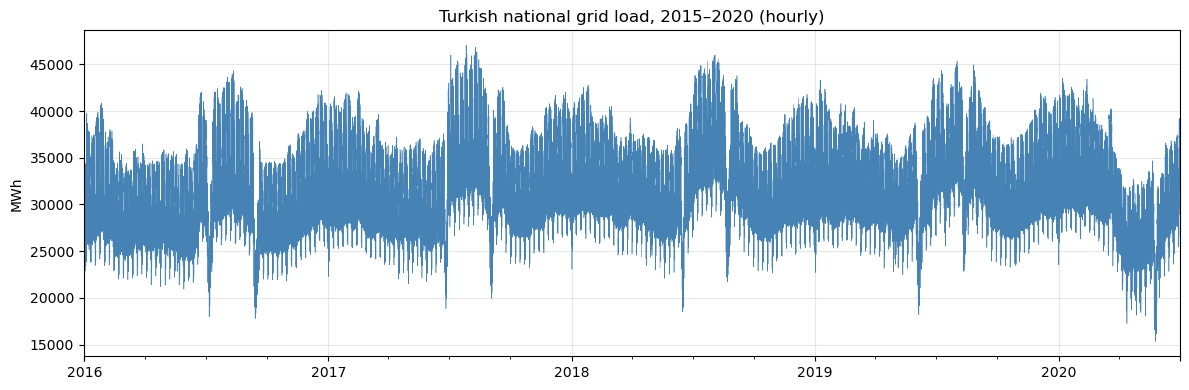

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
series.plot(ax=ax, linewidth=0.4, color="steelblue")
ax.set(title="Turkish national grid load, 2015–2020 (hourly)",
       ylabel="MWh", xlabel="")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Feature engineering

Every feature is shifted by at least the forecast horizon (24 h). Rolling stats
are computed on the shifted series so no window can peek at the target.

In [6]:
frame = make_features(series, min_lag=HORIZON, country=COUNTRY)
print(f"Frame: {frame.shape[0]:,} rows × {frame.shape[1] - 1} features")
print(f"Range: {frame.index.min()} → {frame.index.max()}")
frame.head(3)

Frame: 38,736 rows × 61 features
Range: 2016-01-30 00:00:00 → 2020-06-30 23:00:00


,y,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,lag_32,...,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,is_holiday,is_holiday_eve,t_index
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-30 00:00:00,30323.74,30705.61,33343.43,34799.91,34747.11,35585.73,36504.46,38081.88,39566.36,39101.10,...,1.000000,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,720
2016-01-30 01:00:00,28528.18,29000.54,30705.61,33343.43,34799.91,34747.11,35585.73,36504.46,38081.88,39566.36,...,0.965926,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,721
2016-01-30 02:00:00,27243.18,27852.55,29000.54,30705.61,33343.43,34799.91,34747.11,35585.73,36504.46,38081.88,...,0.866025,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,722


## 4. Backtest protocol

Four expanding folds, 90-day test windows each, with a 24-hour gap between
train and test so no training row is younger than the earliest test point.

In [7]:
splitter = make_splitter(n_splits=N_FOLDS)
describe_folds(frame, splitter)

,fold,train_hours,train_end,test_start,test_end,test_hours
0,1,30072,2019-07-05,2019-07-07,2019-10-04,2160
1,2,32232,2019-10-03,2019-10-05,2020-01-02,2160
2,3,34392,2020-01-01,2020-01-03,2020-04-01,2160
3,4,36552,2020-03-31,2020-04-02,2020-06-30,2160


## 5. Baselines and models

- **Seasonal naive** — same hour, yesterday (`t-24`)
- **Weekly naive** — same hour, same weekday last week (`t-168`)
- **Ridge, Random Forest, LightGBM** — same feature frame for all three
- **LSTM** — same information (72-hour sequence plus calendar and seasonal lags)

In [8]:
results = [
    backtest_baseline(frame, "lag_24",  "Seasonal naive (t-24)", splitter),
    backtest_baseline(frame, "lag_168", "Weekly naive (t-168)",  splitter),
]
predictions, importance_tables = [], {}

for name, factory in {
    "Ridge":         make_ridge,
    "Random Forest": make_random_forest,
    "LightGBM":      make_gbm,
}.items():
    print(f"Backtesting {name:<15s}", end=" ", flush=True)
    fold_results, importance, preds = backtest_model(
        frame, factory, name, splitter, collect_predictions=True,
    )
    print(f"mean MAE {fold_results['MAE'].mean():,.1f}")
    results.append(fold_results)
    predictions.append(preds)
    if importance is not None:
        importance_tables[name] = importance

Backtesting Ridge           mean MAE 1,127.6
Backtesting Random Forest   mean MAE 833.7
Backtesting LightGBM        mean MAE 841.8


In [9]:
if RUN_LSTM:
    from src.lstm_backtest import backtest_lstm
    print("Backtesting LSTM — this takes 5–10 minutes ...")
    lstm_results, lstm_preds = backtest_lstm(series, frame, splitter)
    print(f"LSTM mean MAE {lstm_results['MAE'].mean():,.1f}")
    results.append(lstm_results.drop(columns=["epochs"], errors="ignore"))
    predictions.append(lstm_preds)

Backtesting LSTM — this takes 5–10 minutes ...
LSTM mean MAE 792.3


### Headline table

In [10]:
all_results = pd.concat(results,     ignore_index=True)
all_preds   = pd.concat(predictions, ignore_index=True)

summary = summarise(all_results, baseline_name="Seasonal naive")
summary

,MAE_mean,MAE_std,RMSE_mean,MAPE_mean,fit_s,vs_baseline_%
model,,,,,,
LSTM,792.34,258.90,1161.57,2.60,105.18,57.7
Random Forest,833.74,353.12,1245.31,2.81,55.38,55.5
LightGBM,841.79,320.44,1228.97,2.79,6.18,55.0
Ridge,1127.62,240.70,1483.83,3.67,0.10,39.8
Weekly naive (t-168),1719.63,626.93,2535.71,5.57,0.00,8.2
Seasonal naive (t-24),1872.50,62.35,2944.25,5.98,0.00,0.0


### Per-fold stability

In [11]:
pivot = (all_results.pivot_table(index="model", columns="fold", values="MAE")
                    .round(1))
pivot

fold,1,2,3,4
model,,,,
LSTM,764.1,535.9,717.9,1151.5
LightGBM,819.7,524.3,738.5,1284.6
Random Forest,760.3,511.8,725.7,1337.1
Ridge,1134.7,858.2,1076.0,1441.5
Seasonal naive (t-24),1921.5,1845.3,1926.0,1797.3
Weekly naive (t-168),2374.5,1017.0,1386.2,2100.8


## 6. Feature importance

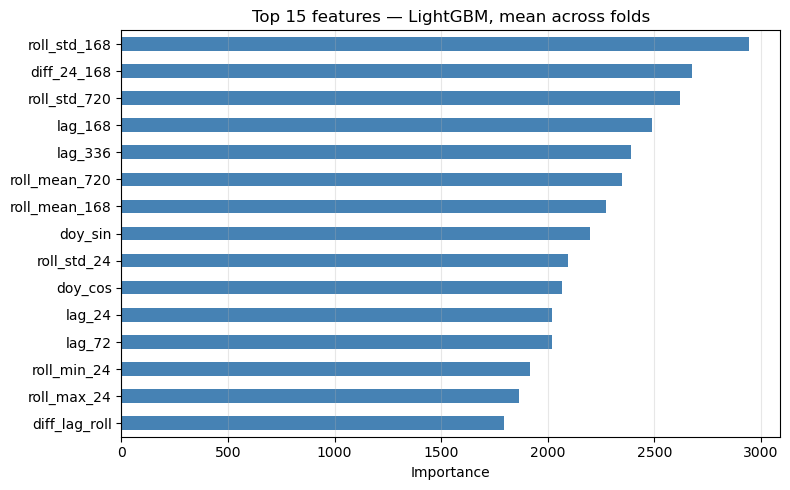

In [12]:
if "LightGBM" in importance_tables:
    top = importance_tables["LightGBM"].head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    top.iloc[::-1].plot.barh(ax=ax, color="steelblue")
    ax.set(title="Top 15 features — LightGBM, mean across folds",
           xlabel="Importance")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout(); plt.show()
    top.head(6)

## 7. Error analysis on the production model

Everything below uses LightGBM (the production choice per the README).

In [13]:
PROD = "LightGBM"
prod_preds = all_preds[all_preds["model"] == PROD]
print(f"Predictions used for error analysis: {len(prod_preds):,} rows")

Predictions used for error analysis: 8,640 rows


### By demand period (terciles of hourly mean load)

In [14]:
error_by_period(prod_preds, series)

,MAE,MAPE_pct,mean_load,bias,n
period,,,,,
Off-peak,553.31,2.07,28368.12,-71.88,2880
Transition,966.38,3.22,33429.93,76.85,2880
Peak,1005.69,3.09,35247.09,52.90,2880


### By hour of day, MAE and signed bias

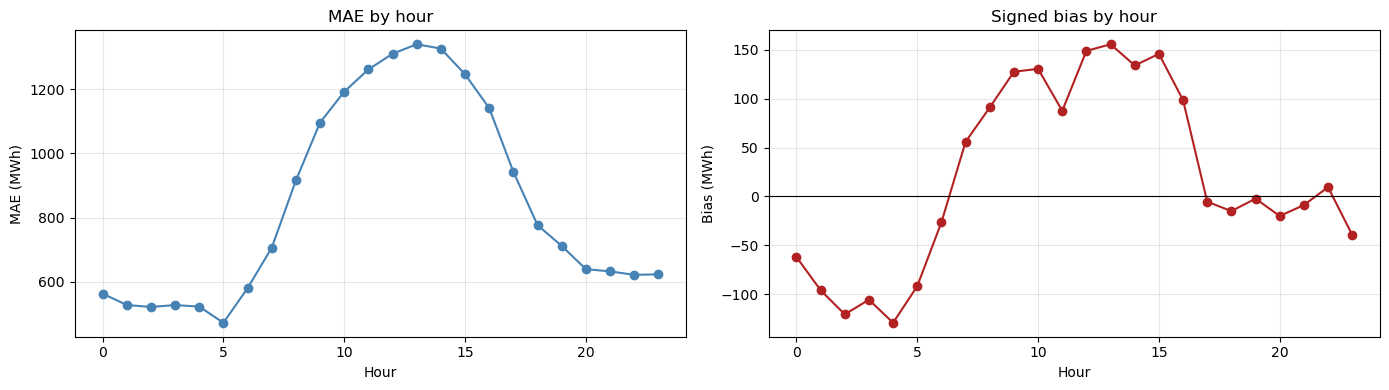

In [15]:
hour_err = error_by_hour(prod_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hour_err["MAE"].plot(ax=axes[0], color="steelblue", marker="o")
axes[0].set(title="MAE by hour", ylabel="MAE (MWh)", xlabel="Hour")
axes[0].grid(alpha=0.3)

hour_err["bias"].plot(ax=axes[1], color="firebrick", marker="o")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="Signed bias by hour", ylabel="Bias (MWh)", xlabel="Hour")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### By day type

In [16]:
error_by_day_type(prod_preds, COUNTRY)

,MAE,MAPE_pct,n
segment,,,
Public holiday,2015.42,8.33,336
Weekend,876.02,3.20,2424
Normal day,760.61,2.31,5880
Friday,622.85,1.92,1176
Monday,1076.35,3.25,1176
Thursday,629.13,1.85,1200
Tuesday,809.39,2.48,1152
Wednesday,669.03,2.06,1176


## 8. The 2020 demand shock

Fold 4 (April–June 2020) is a real distribution shift. Learned models degraded
sharply while the naive baselines held — the signature of regime change, not a
modelling bug.

### Before vs after 2020-03-16

In [17]:
regime_shift_split(prod_preds, cut="2020-03-16")

,MAE,RMSE,MAPE_pct,n
Before,659.57,996.30,1.93,6072.00
After,1272.66,1793.56,4.83,2568.00
Degradation_x,1.93,1.80,2.50,0.42


### 2020 weekly load vs the same ISO weeks in 2019

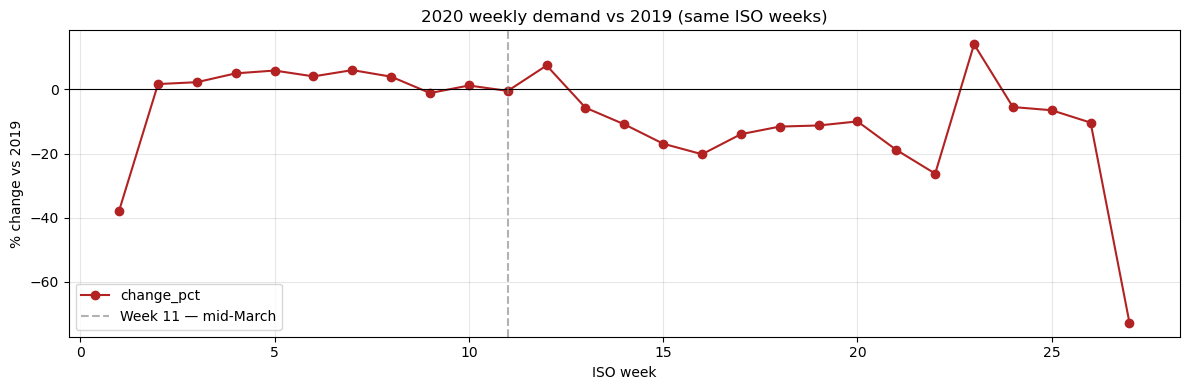

,2019_MWh,2020_MWh,change_pct
week,,,
1,6390011.75,3975736.74,-37.78
2,5920083.56,6018101.31,1.66
3,5815839.77,5946237.90,2.24
4,5646632.33,5928956.85,5.00
5,5501182.70,5824228.39,5.87
6,5665688.17,5895080.93,4.05
7,5703886.19,6046758.28,6.01
8,5607916.08,5829936.33,3.96
9,5693349.44,5627825.49,-1.15


In [18]:
yoy = year_over_year_load(series, baseline_year=2019, shock_year=2020)

fig, ax = plt.subplots(figsize=(12, 4))
yoy["change_pct"].plot(ax=ax, color="firebrick", marker="o")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(11, color="grey", linestyle="--", alpha=0.6,
           label="Week 11 — mid-March")
ax.set(title="2020 weekly demand vs 2019 (same ISO weeks)",
       ylabel="% change vs 2019", xlabel="ISO week")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

yoy.head(15)

## 9. Retraining cadence, fold 4

Same model, same features, same evaluation window — only the deployment
cadence differs.

In [19]:
cadence = cadence_comparison(
    frame, make_gbm,
    cadences={"Train once": None, "Retrain weekly": 7},
    fold=N_FOLDS,
    splitter=splitter,
)
cadence

,MAE,RMSE,MAPE_%,cadence_days
strategy,,,,
Train once,1284.63,1830.65,5.02,0
Retrain weekly,1154.93,1674.89,4.46,7


## 10. Prediction intervals

Quantile GBMs at the 5th, 50th and 95th percentiles. These raw intervals are
under-calibrated out of sample — the CQR helper in `src/intervals.py` is the
intended fix (README limitation #2).

In [20]:
interval_fold, interval_preds = backtest_quantiles(frame, splitter)
interval_fold[["fold", "coverage_pct", "target_coverage_pct",
               "mean_width", "pinball_med"]]

,fold,coverage_pct,target_coverage_pct,mean_width,pinball_med
0,1,67.592593,90.0,2159.355643,397.142468
1,2,67.453704,90.0,1413.414963,255.768687
2,3,72.083333,90.0,2153.767077,370.938881
3,4,55.740741,90.0,2506.072262,685.001185


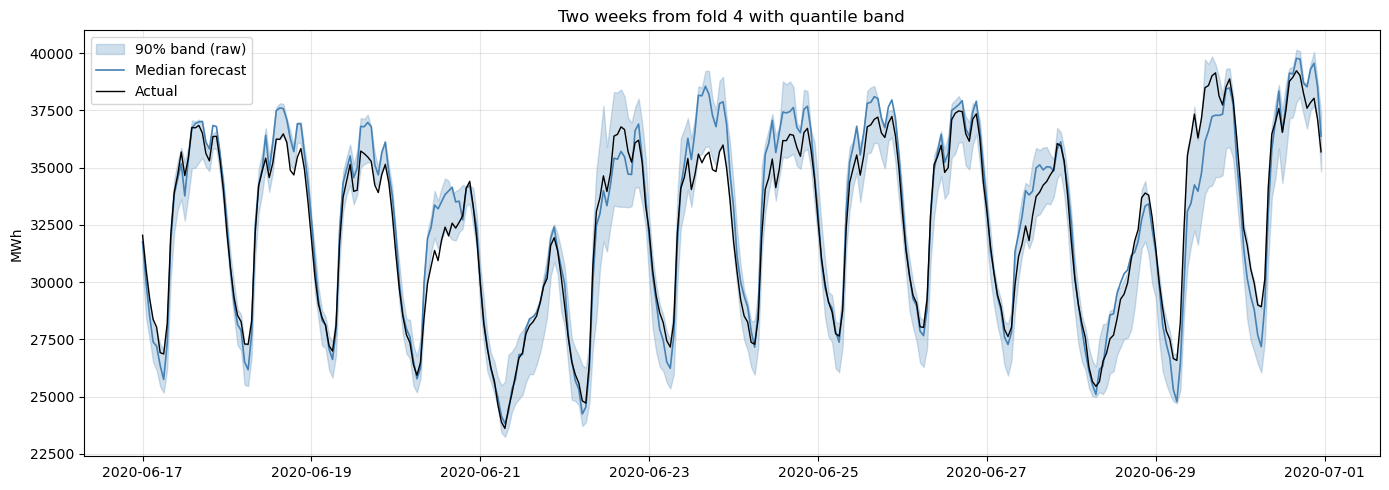

In [21]:
last = interval_preds["fold"].max()
window = (interval_preds[interval_preds["fold"] == last]
          .tail(24 * 14).set_index("datetime"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(window.index, window["q05"], window["q95"],
                color="steelblue", alpha=0.25, label="90% band (raw)")
ax.plot(window.index, window["q50"],   color="steelblue",
        linewidth=1.2, label="Median forecast")
ax.plot(window.index, window["y_true"], color="black",
        linewidth=1, label="Actual")
ax.set(title=f"Two weeks from fold {last} with quantile band",
       ylabel="MWh")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Save artifacts

Everything MLflow, the Streamlit dashboard and the FastAPI service will read.

In [22]:
all_results.to_csv(OUTPUT_DIR / "backtest_results.csv", index=False)
summary.to_csv    (OUTPUT_DIR / "backtest_summary.csv")
all_preds.to_csv  (OUTPUT_DIR / "predictions.csv", index=False)

for name, imp in importance_tables.items():
    slug = name.lower().replace(" ", "_")
    imp.to_csv(OUTPUT_DIR / f"importance_{slug}.csv")

error_by_period (prod_preds, series ).to_csv(OUTPUT_DIR / "error_by_period.csv")
error_by_hour   (prod_preds         ).to_csv(OUTPUT_DIR / "error_by_hour.csv")
error_by_day_type(prod_preds, COUNTRY).to_csv(OUTPUT_DIR / "error_by_day_type.csv")
regime_shift_split(prod_preds       ).to_csv(OUTPUT_DIR / "regime_shift.csv")
year_over_year_load(series, 2019, 2020).to_csv(OUTPUT_DIR / "yoy_load.csv")

cadence.to_csv        (OUTPUT_DIR / "retraining_cadence.csv")
interval_fold.to_csv  (OUTPUT_DIR / "intervals_by_fold.csv", index=False)
interval_preds.to_csv (OUTPUT_DIR / "intervals_predictions.csv", index=False)

print(f"All artifacts written to {OUTPUT_DIR.resolve()}")

All artifacts written to C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\electricity-consumption-forecasting-main\outputs
